# 3. Model recovery and model comparison

> **Level** Intermediate · **Time** 30 minutes · **Prerequisites** [2. Parameter recovery](parameter-recovery.ipynb) ·
> **cpm components** [`Simulator`](#cpm.generators.Simulator), [`FminBound`](#cpm.optimisation.FminBound), [`PenalisedLikelihoods`](#cpm.optimisation.compare.PenalisedLikelihoods) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data)

When we compare models on real data, we want the model that best explains the data to win.
But can the comparison tell our models apart at all?
In a model recovery study, we simulate data from each candidate model, fit all candidate models to every simulated dataset, and check how often the model that generated the data also fits it best (Wilson & Collins, 2019).

**What you'll learn**

- how to write several competing models that share most of their code,
- how to compare fitted models with the Bayesian information criterion (BIC),
- how to build and read a model recovery confusion matrix,
- how to see how distinguishable two models are with a landscape (Navarro et al., 2004).

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)

0.25.7.dev0


## Three models of the bandit task

All three models learn a value $Q$ for each of the four stimuli of the two-armed bandit task from [Tutorial 1](first-model.ipynb), and choose with a Softmax rule with inverse temperature $\beta$.
They differ in how they update the values after a choice, where $c$ is the chosen stimulus, $u$ the stimulus that was on screen but not chosen, $R$ the reward, and $\alpha$ the learning rate.

**Delta rule.** Only the chosen stimulus is updated, towards the reward (Rescorla & Wagner, 1972):

$$
Q(c) \leftarrow Q(c) + \alpha \left[ R - Q(c) \right]
$$

**Counterfactual.** The model assumes that when one stimulus pays out, the other would not have, so it also updates the unchosen stimulus towards the opposite outcome:

$$
Q(c) \leftarrow Q(c) + \alpha \left[ R - Q(c) \right], \qquad Q(u) \leftarrow Q(u) + \alpha \left[ (1 - R) - Q(u) \right]
$$

**Choice kernel.** The model ignores the reward, and learns how often it chose each stimulus, so it tends to repeat its choices (Wilson & Collins, 2019):

$$
Q(c) \leftarrow Q(c) + \alpha \left[ 1 - Q(c) \right], \qquad Q(u) \leftarrow Q(u) + \alpha \left[ 0 - Q(u) \right]
$$

Because the models only differ in their targets, we write one model function, and pass it the targets of each model.

In [2]:
from functools import partial

from cpm.datasets import load_bandit_data
from cpm.generators import Parameters, Value, Wrapper
from cpm.models.decision import Softmax


# the targets of the chosen and the unchosen stimulus, given the reward
def delta(reward):
    return reward, None


def counterfactual(reward):
    return reward, 1 - reward


def choice_kernel(reward):
    return 1, 0


def model(parameters, trial, targets, generate=False):
    values = np.asarray(parameters.values).copy()
    stimuli = np.array([trial.arm_left, trial.arm_right]).astype(int) - 1
    rewards = np.array([trial.reward_left, trial.reward_right])

    choice_rule = Softmax(activations=values[stimuli], temperature=parameters.temperature)
    choice_rule.compute()
    choice = choice_rule.choice() if generate else int(trial.response)

    chosen, unchosen = stimuli[choice], stimuli[1 - choice]
    target_chosen, target_unchosen = targets(rewards[choice])
    values[chosen] += parameters.alpha * (target_chosen - values[chosen])
    if target_unchosen is not None:
        values[unchosen] += parameters.alpha * (target_unchosen - values[unchosen])

    return {
        "policy": choice_rule.policies,
        "response": choice,
        "values": values,
        "dependent": np.array([choice_rule.policies[1]]),
    }


parameters = Parameters(
    alpha=Value(value=0.5, lower=1e-10, upper=1, prior="truncated_normal", args={"mean": 0.5, "sd": 0.25}),
    temperature=Value(value=1, lower=0, upper=10, prior="truncated_normal", args={"mean": 5, "sd": 2.5}),
    values=np.array([0.25, 0.25, 0.25, 0.25]),
)
models = {"delta": delta, "counterfactual": counterfactual, "choice kernel": choice_kernel}

We simulate 100 agents per model, using the trial sequences of the first 100 participants of the bandit dataset.

In [3]:
data = load_bandit_data()
data = data[data.ppt <= 100].reset_index(drop=True)
data["observed"] = data["response"]  # replaced by the simulated choices
print(f"{data.ppt.nunique()} trial sequences of {data.groupby('ppt').size().iloc[0]} trials")

100 trial sequences of 71 trials


## Comparing fitted models

To compare models, we need a measure of fit that accounts for the number of parameters, because a more flexible model can fit noise.
The Bayesian information criterion (BIC) penalises the log-likelihood $\log L$ of a fit by the number of free parameters $k$ and the number of data points $n$:

$$
\text{BIC} = -2 \log L + k \log n
$$

Lower is better.
Our three models have the same number of parameters, so here BIC ranks them in the same order as the likelihood, but the same code works for models of different complexity.
We ask the optimiser to compute the BIC of each participant at the best-fitting parameters with the `metrics` argument, using [`PenalisedLikelihoods.BIC`](#cpm.optimisation.compare.PenalisedLikelihoods.BIC).

In [4]:
from cpm.generators import Simulator
from cpm.optimisation import FminBound, minimise
from cpm.optimisation.compare import PenalisedLikelihoods


def simulate(targets, data):
    '''Simulate choices from a model, with parameters sampled from their priors.'''
    generative = Wrapper(model=partial(model, targets=targets, generate=True), parameters=parameters, data=data[data.ppt == 1])
    true_parameters = pd.DataFrame(parameters.sample(size=data.ppt.nunique()))
    simulator = Simulator(wrapper=generative, parameters=true_parameters, data=data.groupby("ppt"))
    simulator.run()
    simulated = data.copy()
    simulated["response"] = simulator.export()["response"].to_numpy()
    simulated["observed"] = simulated["response"]
    return simulated


def fit(targets, data):
    '''Fit a model to every participant, and return the fit of each participant.'''
    fitting = Wrapper(model=partial(model, targets=targets), parameters=parameters, data=data[data.ppt == 1])
    optimiser = FminBound(
        model=fitting,
        data=data.groupby("ppt"),
        minimisation=minimise.LogLikelihood.bernoulli,
        metrics={"BIC": PenalisedLikelihoods.BIC},
        prior=False,
        number_of_starts=2,
        ppt_identifier="ppt",
        parallel=False,
        display=False,
        approx_grad=True,
    )
    optimiser.optimise()
    return optimiser.export()[["ppt", "fun", "BIC"]]

## Model recovery

For each model, we simulate a dataset, and fit all three models to it.
This runs 9 fits of 100 participants, which takes a few minutes.

In [5]:
fits = []
for generating_name, generating_targets in models.items():
    simulated = simulate(generating_targets, data)
    for fitted_name, fitted_targets in models.items():
        result = fit(fitted_targets, simulated)
        result["generating model"] = generating_name
        result["fitted model"] = fitted_name
        fits.append(result)
fits = pd.concat(fits, ignore_index=True)
fits.head()

,ppt,fun,BIC,generating model,fitted model
0,1,28.619182,65.763723,delta,delta
1,2,42.635878,93.825087,delta,delta
2,3,11.949914,32.453160,delta,delta
3,4,25.144123,58.841578,delta,delta
4,5,19.755997,48.065326,delta,delta


For every simulated participant, the winning model is the one with the lowest BIC.
The confusion matrix shows, for each generating model (rows), how often each model won (columns).
If the models are recoverable, the matrix is close to diagonal.

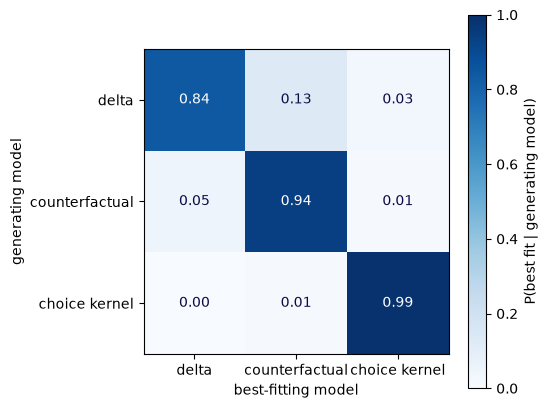

In [6]:
winners = fits.loc[fits.groupby(["generating model", "ppt"])["BIC"].idxmin()]
names = list(models)
confusion = (
    pd.crosstab(winners["generating model"], winners["fitted model"], normalize="index")
    .reindex(index=names, columns=names, fill_value=0)
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
image = ax.imshow(confusion.to_numpy(), cmap="Blues", vmin=0, vmax=1)
for i in range(len(names)):
    for j in range(len(names)):
        value = confusion.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "#0c0c45")
ax.set_xticks(range(len(names)), names)
ax.set_yticks(range(len(names)), names)
ax.set_xlabel("best-fitting model")
ax.set_ylabel("generating model")
fig.colorbar(image, ax=ax, label="P(best fit | generating model)")
plt.tight_layout()
plt.show()

Recovery is good for all three models: most simulated participants are best fitted by the model that generated their data.
The choice kernel is recovered almost perfectly, because its choices do not depend on the rewards at all.
The main confusion is between the delta rule and the counterfactual model: both learn to prefer the stimulus that pays out more, so for some agents, especially those whose choices are noisy, the data do not tell them apart.
If the confusion matrix of your own candidate models has large entries off the diagonal, a comparison of those models on real data will be inconclusive, however good the fits.

## Landscaping

A landscape (Navarro et al., 2004) shows the same information for a pair of models, one participant at a time.
For each simulated participant, we plot the log-likelihood of one model against the log-likelihood of the other.
Points on the diagonal are fitted equally well by both models; the further they fall from the diagonal, the easier the two models are to tell apart.

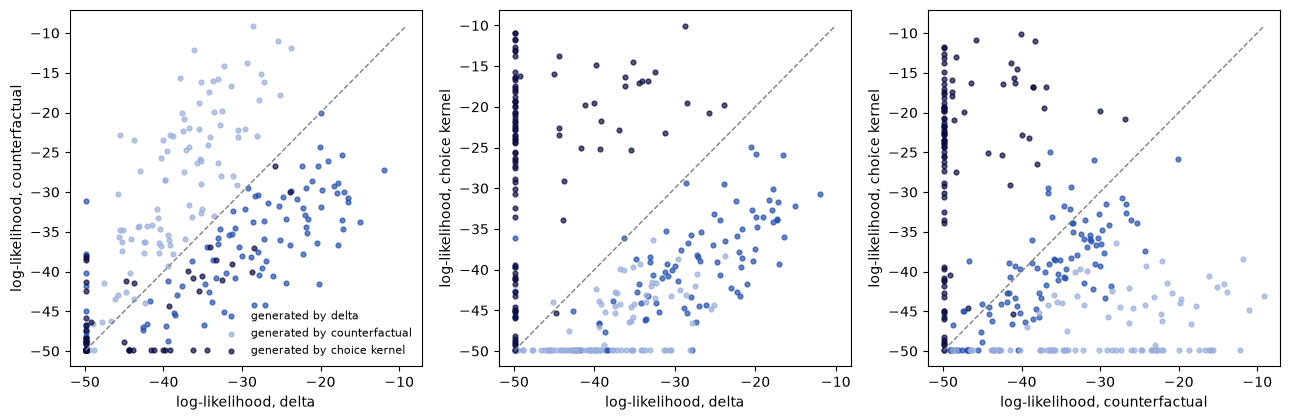

In [7]:
loglik = fits.assign(loglik=-fits["fun"]).pivot_table(
    index=["generating model", "ppt"], columns="fitted model", values="loglik"
)
pairs = [("delta", "counterfactual"), ("delta", "choice kernel"), ("counterfactual", "choice kernel")]
colours = {"delta": "#2350b0", "counterfactual": "#98aedd", "choice kernel": "#0c0c45"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (x_model, y_model) in zip(axes, pairs):
    for generating_name in names:
        subset = loglik.loc[generating_name]
        ax.scatter(subset[x_model], subset[y_model], s=12, alpha=0.7, color=colours[generating_name], label=f"generated by {generating_name}")
    limits = [loglik[[x_model, y_model]].min().min(), loglik[[x_model, y_model]].max().max()]
    ax.plot(limits, limits, color="grey", linestyle="--", linewidth=1)
    ax.set_xlabel(f"log-likelihood, {x_model}")
    ax.set_ylabel(f"log-likelihood, {y_model}")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In each landscape, the data of each generating model fall mostly on the side of the diagonal of the model that generated them, so the three models can be told apart in this task.
The delta rule and the counterfactual model are the closest pair: more of their points lie near the diagonal.

Many fits pile up at a log-likelihood of about −49, which is $71 \log 0.5$: the log-likelihood of predicting every one of the 71 choices with a probability of 0.5.
This is where a model ends up when it cannot explain the choices at all, and sets its inverse temperature to 0.
For example, neither the delta rule nor the counterfactual model can explain the choices of a choice kernel agent, whose choices do not depend on the rewards.

## Summary and next steps

You simulated data from three models, fitted every model to every dataset, and compared the fits with BIC.
The confusion matrix and the landscapes show which models this task can tell apart, before you compare the models on real data.

So far, we have fitted each participant separately.
When participants have few trials, their estimates are noisy; hierarchical estimation uses the whole group to improve them.
That is the topic of [4. Hierarchical estimation I: empirical Bayes](hierarchical-empirical-bayes.ipynb).

## References

Navarro, D. J., Pitt, M. A., & Myung, I. J. (2004). Assessing the distinguishability of models and the informativeness of data. *Cognitive Psychology*, 49(1), 47–84. https://doi.org/10.1016/j.cogpsych.2003.11.001

Rescorla, R. A., & Wagner, A. R. (1972). A theory of Pavlovian conditioning: Variations in the effectiveness of reinforcement and nonreinforcement. In A. H. Black & W. F. Prokasy (Eds.), *Classical conditioning II: Current research and theory* (pp. 64–99). Appleton-Century-Crofts.

Wilson, R. C., & Collins, A. G. E. (2019). Ten simple rules for the computational modeling of behavioral data. *eLife*, 8, e49547. https://doi.org/10.7554/eLife.49547